# 2. Data Collection and Cleaning

Begin the data understanding process by loading the customer dataset, examining the variables, and identifying any missing values.

## 2.1. Load necessary libraries

In [40]:
import matplotlib.pyplot as plt # Data visualization
import matplotlib.patheffects as pe
import numpy as np # linear algebra
import pandas as pd # Data processing
from pathlib import Path

import missingno as msno # Analyze data for missing values

%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.family'] = 'sans-serif'

## 2.2. Loading the dataset

Saving the path to directories for raw and processed data in variables for more convenient work. 

In [41]:
project_root = Path.cwd().parent
raw_data_directory_path = project_root / "data" / "raw"
processed_data_directory_path = project_root / "data" / "processed"

Loading raw data with the first and last 5 rows displayed. This is followed by the display of information about the dataset, including the index data type, columns, and non-null values.

In [42]:
df = pd.read_csv(raw_data_directory_path / "e-commerce-data-raw.csv", encoding = "ISO-8859-1")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


Upon loading the dataset, it was ascertained that it determined ***541909*** records (rows) and ***8*** attributes (columns). The columns of the dataset can be described in the following way: 
- 4 columns are a numeric type of data;
- 2 text type (In case of making a dashboard report, it is possible to change the `Country` column to a geographical data type);
- 1 date/time column - `InvoiceDate` which should be transformed into two separate columns `InvoiceDate` and `InvoiceTime`.

The brief
|**№**  |**Column name**|**Column description**|**Data type**|
|:-----:|:--------------|:---------------------|:-----------:|
|1      |**InvoiceNo**  |A unique identifier assigned to each transaction|object|
|2      |**StockCode**  |An internationally standardized system of names and numbers to classify traded products|object|
|3      |**Description**|A description of the trade product|object|
|4      |**Quantity**   |The quantity of units of a product in a transaction|int64 |
|5      |**InvoiceDate**|The date and time of the transaction|object|
|6      |**UnitPrice**  |The unit price of the product is expressed in sterling|float64|
|7      |**CustomerID** |A unique identifier assigned to each customer|float64|
|8      |**Country**    |The country of the customer|object|

To continue working with the dataset, the next step will be to standardize the column headers.

In [44]:
df = df.rename(columns = {
    "InvoiceNo": "invoice_number",
    "StockCode": "stock_code",
    "Description": "description",
    "Quantity": "quantity",
    "InvoiceDate": "invoice_date",
    "UnitPrice": "unit_price",
    "CustomerID": "customer_id",
    "Country": "country"
})

df.head()

,invoice_number,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 2.3. Preliminary summary analysis

Before starting the data cleaning procedure, it is necessary to survey the summary statistics of the entire dataset. This will provide the initial insights into the data distribution and identify any inconsistencies that could affect on the analysis.

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
unit_price,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
customer_id,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [46]:
df['customer_id'] = df['customer_id'].astype('object')

In [47]:
df.describe(include = ["object", "string"]).T

,count,unique,top,freq
invoice_number,541909,25900,573585,1114
stock_code,541909,4070,85123A,2313
description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
invoice_date,541909,23260,10/31/2011 14:41,1114
customer_id,406829.0,4372.0,17841.0,7983.0
country,541909,38,United Kingdom,495478


**Results and conclusions for each column**

The following are the initial results of the analysis, which are also questions that should be answered in future steps.
1. Quantity:
    - The significant difference between the **mean** ($\approx 9.55$) and the **median** ($3.00$). This should be considered to understand and analyze the distribution form;
    - The **min** value ($\text{-80995.0}$) should be considered and surveyed, which suggests an unexpected business event like returns or cancellations;
    - The huge significant deviation **std** ($\approx 218.08$) along with the significant **max** value ($\text{80995.0}$) on the overall data considering the **75%** percentile value could indicate a high level of skewness and possible presence of outliers in the data.

2. Unit Price:
    - The more than double difference between the **mean** ($4.61$) and and the median (**50%**) ($2.008$). Should be analysed to understand the distribution form, the values suggest a potential for a strong positive skew distribution;
    - The **min** value ($\text{-11062.06}$) should be considered and surveyed, which suggests an unexpected business event like returns or cancellations;
    - The significant difference between **75%** percentile ($4.13$) and **max** value ($\text{38970.0}$), which may indicate that certain luxury items have a significantly higher price, or it may suggest an administrative entry or a substantial outlier.

3. Customer ID:
    - The value of the **count** parameter ($406829.0$) indicates the presence of missing values, which is critical for the current task (customer segmentation). A procedure for cleaning up missing values is required;
    - After converting the `customer_id` to an `object` data type, we obtained additional information:
        - Total of $4372$ **unique** customers, which may include both potential individuals and businesses;
        - One `customer_id` ($17841$) appears **freq** ($7983$) times. Should check transaction of these customers, it could be the most "active" customer or a massive outlier compared to the average.

4. Invoice No:
    - According to the statistical data, the dataset contains $25900$ unique transactions;
    - The `InvoiceNo` - $573585$ appears **freq** $1114$ times. This could indicate a large wholesale client or a very diverse shopping cart.

5. Stock Code:
    - Dataset contains the $4070$ **unique** items;
    - The `Stockcode` $85123A$ appears **unique** $2313$ times, which at this stage of the analysis, can be designated as the best-selling product.

6. Description:
    - The value of the **count** parameter ($540455$) indicates the presence of missing values; 
    - The number of **unique** ($4223$) values ​​differs from the number in the `stock_code` column. This should be looked into further as it may indicate administrative adjustments, damaged items, or "lost" items rather than actual sales. It is also possible that different character cases were used in various item descriptions;
    - The value of the **freq** parameter ($2313$), ​​differs from the value in the `stock_code` column. This could indicate that there are multiple different `stock_code` with the same `description`.

7. Invoice Date:
    - The number of **unique** values ($23260$) is close to the number of unique values ​of `invoice_number` column. This verifies the reliability of the data in relation to this particular aspect;
    - The timestamp ($10/31/2011 14:41$) apperas **freq** $1114$ times. This confirms the assumption that the order was completed by a large wholesale client or through a diverse shopping cart;
    - Considering the format of transaction dates, it is advisable to convert this column to a `datetime` format and split it into separate date and time columns for further analysis.

8. Country:
    - Country ($United Kingdom$) appears among ($38$) **unique** values **freq** ​(​$495478$) times, which is ($\approx 94\%$) of the total number of transactions. This suggests that the data is primarily focused on the United Kingdom market.

## 2.4. Data cleaning and transformation

### 2.4.1. Trim white spaces in the column data

The first step in data cleaning is to trim white spaces in records, in order to standardize data by removing variations from messy imports.

In [48]:
def trim_whitespace(dataframe):
    for i in dataframe.columns:
        if dataframe[i].dtype == 'object':
            dataframe[i] = dataframe[i].str.strip()
        else:
            pass

df.head()

,invoice_number,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### 2.4.2. Improve datetime data
To allow for better analysis, transform the `invoice_date` column to the datetime data format and create two additional columns: `invoice_date` for storing the date only, and `invoice_time` for storing the time only.

In [49]:
df['invoice_datetime'] = pd.to_datetime(df['invoice_date'], format='%m/%d/%Y %H:%M')
df = df.drop(columns = 'invoice_date')
df.head()

,invoice_number,stock_code,description,quantity,unit_price,customer_id,country,invoice_datetime
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01 08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01 08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01 08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01 08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01 08:26:00


In [50]:
df['invoice_date'] = df['invoice_datetime'].dt.date
df['invoice_time'] = df['invoice_datetime'].dt.time
df = df.loc[:, ['invoice_number', 'stock_code', 'description', 'quantity', 'invoice_datetime', 'invoice_date', 'invoice_time', 'unit_price', 'customer_id', 'country']]
df.head()

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010-12-01,08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010-12-01,08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom


### 2.4.3. Detect and fix/drop `NAN` values

The next step is to remove the `NAN` values and duplicates in order to exclude inaccurate initial summary statistics.

First, visualize the number of missing values by using the *missingno* library.

<Axes: >

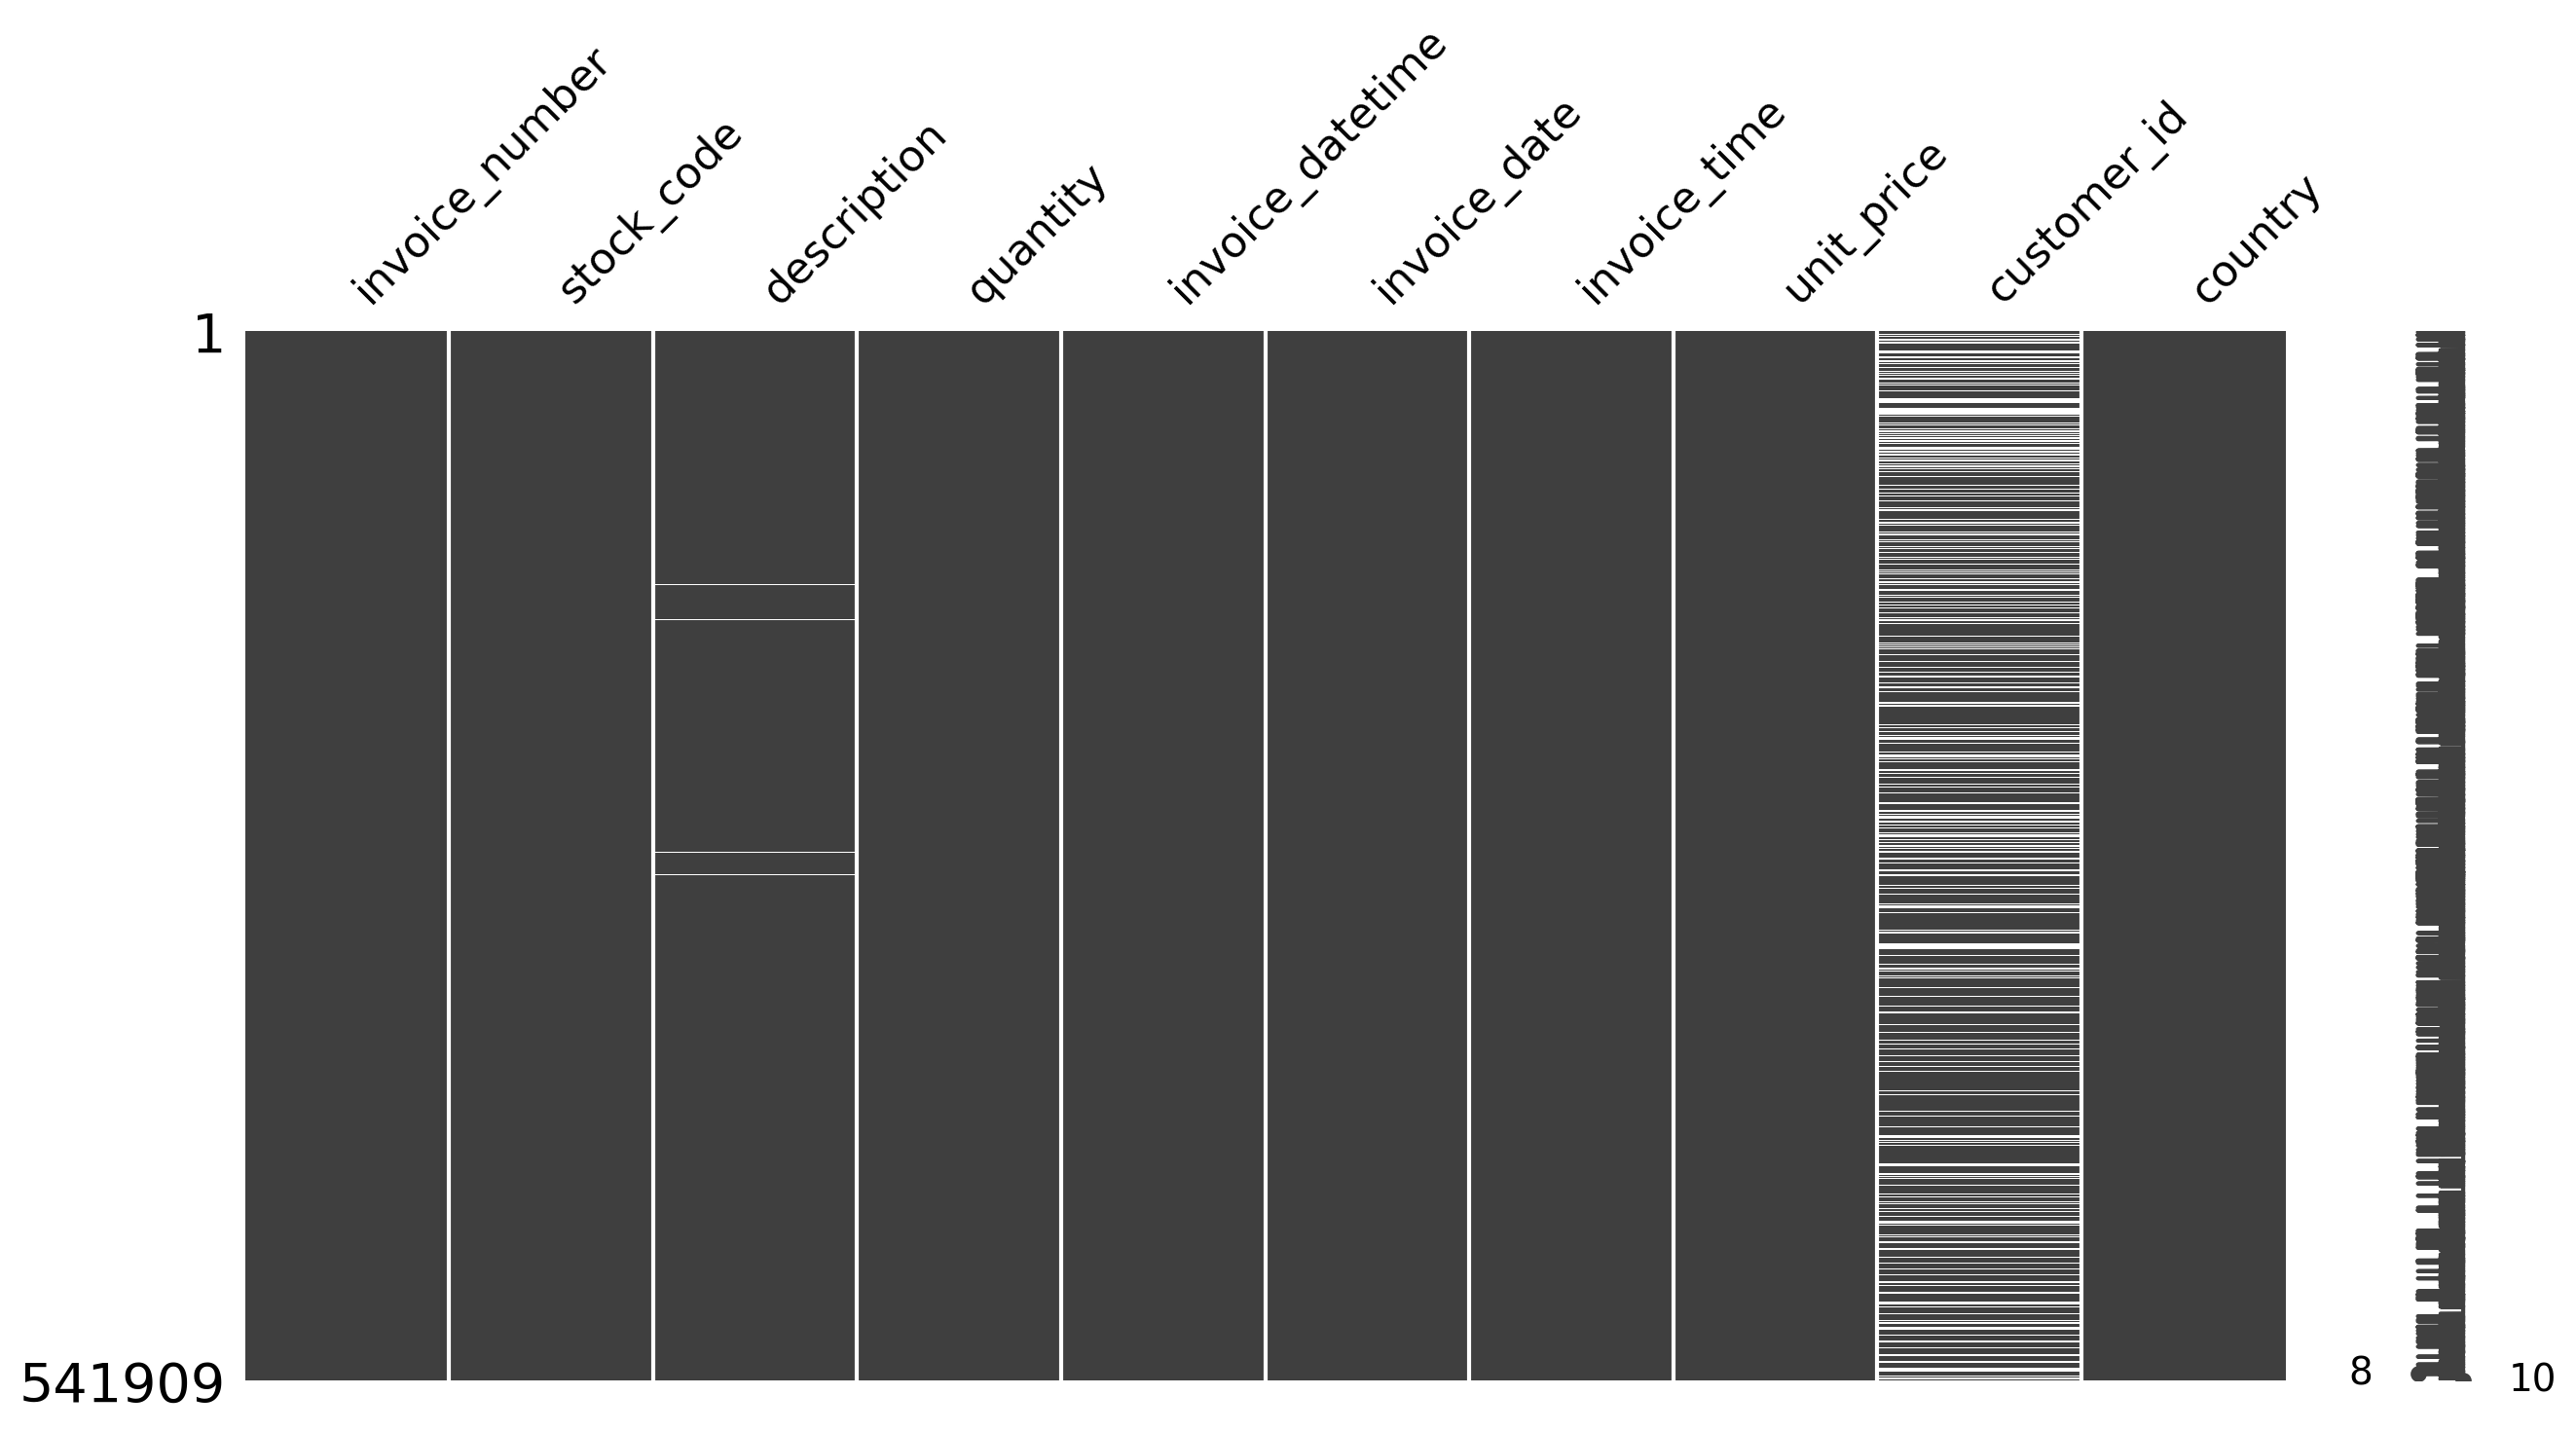

In [51]:
msno.matrix(df, figsize=(15, 7))

Then display the columns containing missing values on the chart, as well as the percentage of the total number of these values.

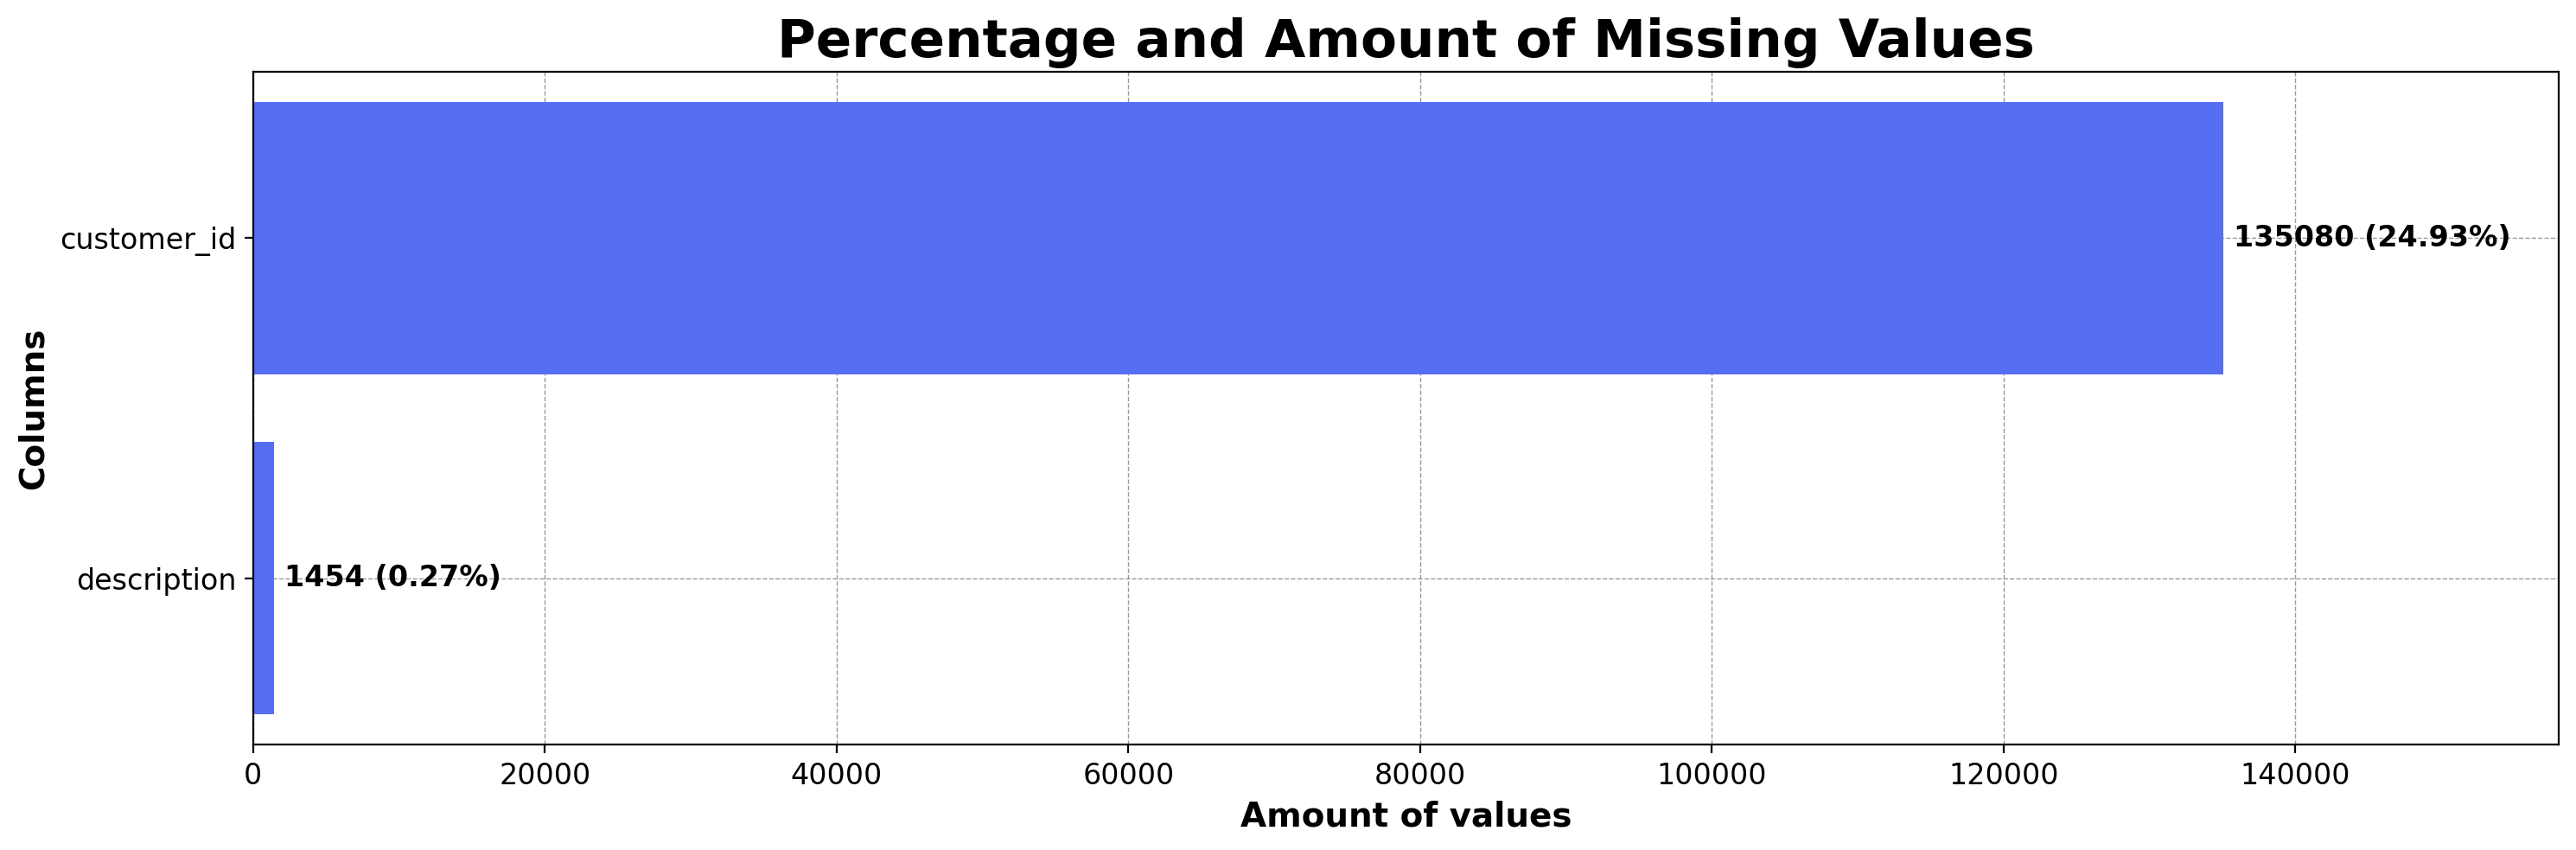

In [52]:
missing_data = df.isnull().sum()
missing_data_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

missing_data = missing_data[missing_data > 0]
missing_data.sort_values(ascending = True, inplace = True)

missing_data_percentage.sort_values(ascending = True, inplace = True)

#================== plot build =======================
fig, ax = plt.subplots(figsize = (15, 5), dpi = 100)
ax.barh(missing_data.index, missing_data, color = "#566ef1")

for i, (value_1, value_2, name) in enumerate(zip(missing_data, missing_data_percentage, missing_data_percentage.index)):
    ax.text(value_1+700, i, f"{value_1} ({value_2:.2f}%)", va = 'center', ha = 'left', fontweight = 'bold', fontsize = 12)

ax.set_xlim([0, value_1*1.17])

#================== plot parameters ==================
plt.title("Percentage and Amount of Missing Values", fontweight = 'bold', fontsize = 22)
plt.xlabel('Amount of values', fontweight = 'bold', fontsize = 14)
plt.ylabel('Columns', fontweight = 'bold', fontsize = 14)
plt.tight_layout()

ax.set_axisbelow(True)
ax.grid(alpha = 0.8, color = 'gray', linestyle = '--', linewidth = 0.5)
ax.tick_params(axis = 'both', labelsize = 12)
plt.tight_layout()
plt.show()

**Analysis of results**

As illustrated in the graph, the number of users without an ID is $135080$, representing $24.93\%$ of the total. Due to the absence of an ID, records without one cannot be included in the analysis for the task of user segmentation. Therefore, there is no other option but to delete them.

The number of missing values in the 'description' columns is $1454$, representing $0.27\%$ of the total. To find out more about missing descriptions, the next graph shows the top 10 stock codes with missing descriptions.

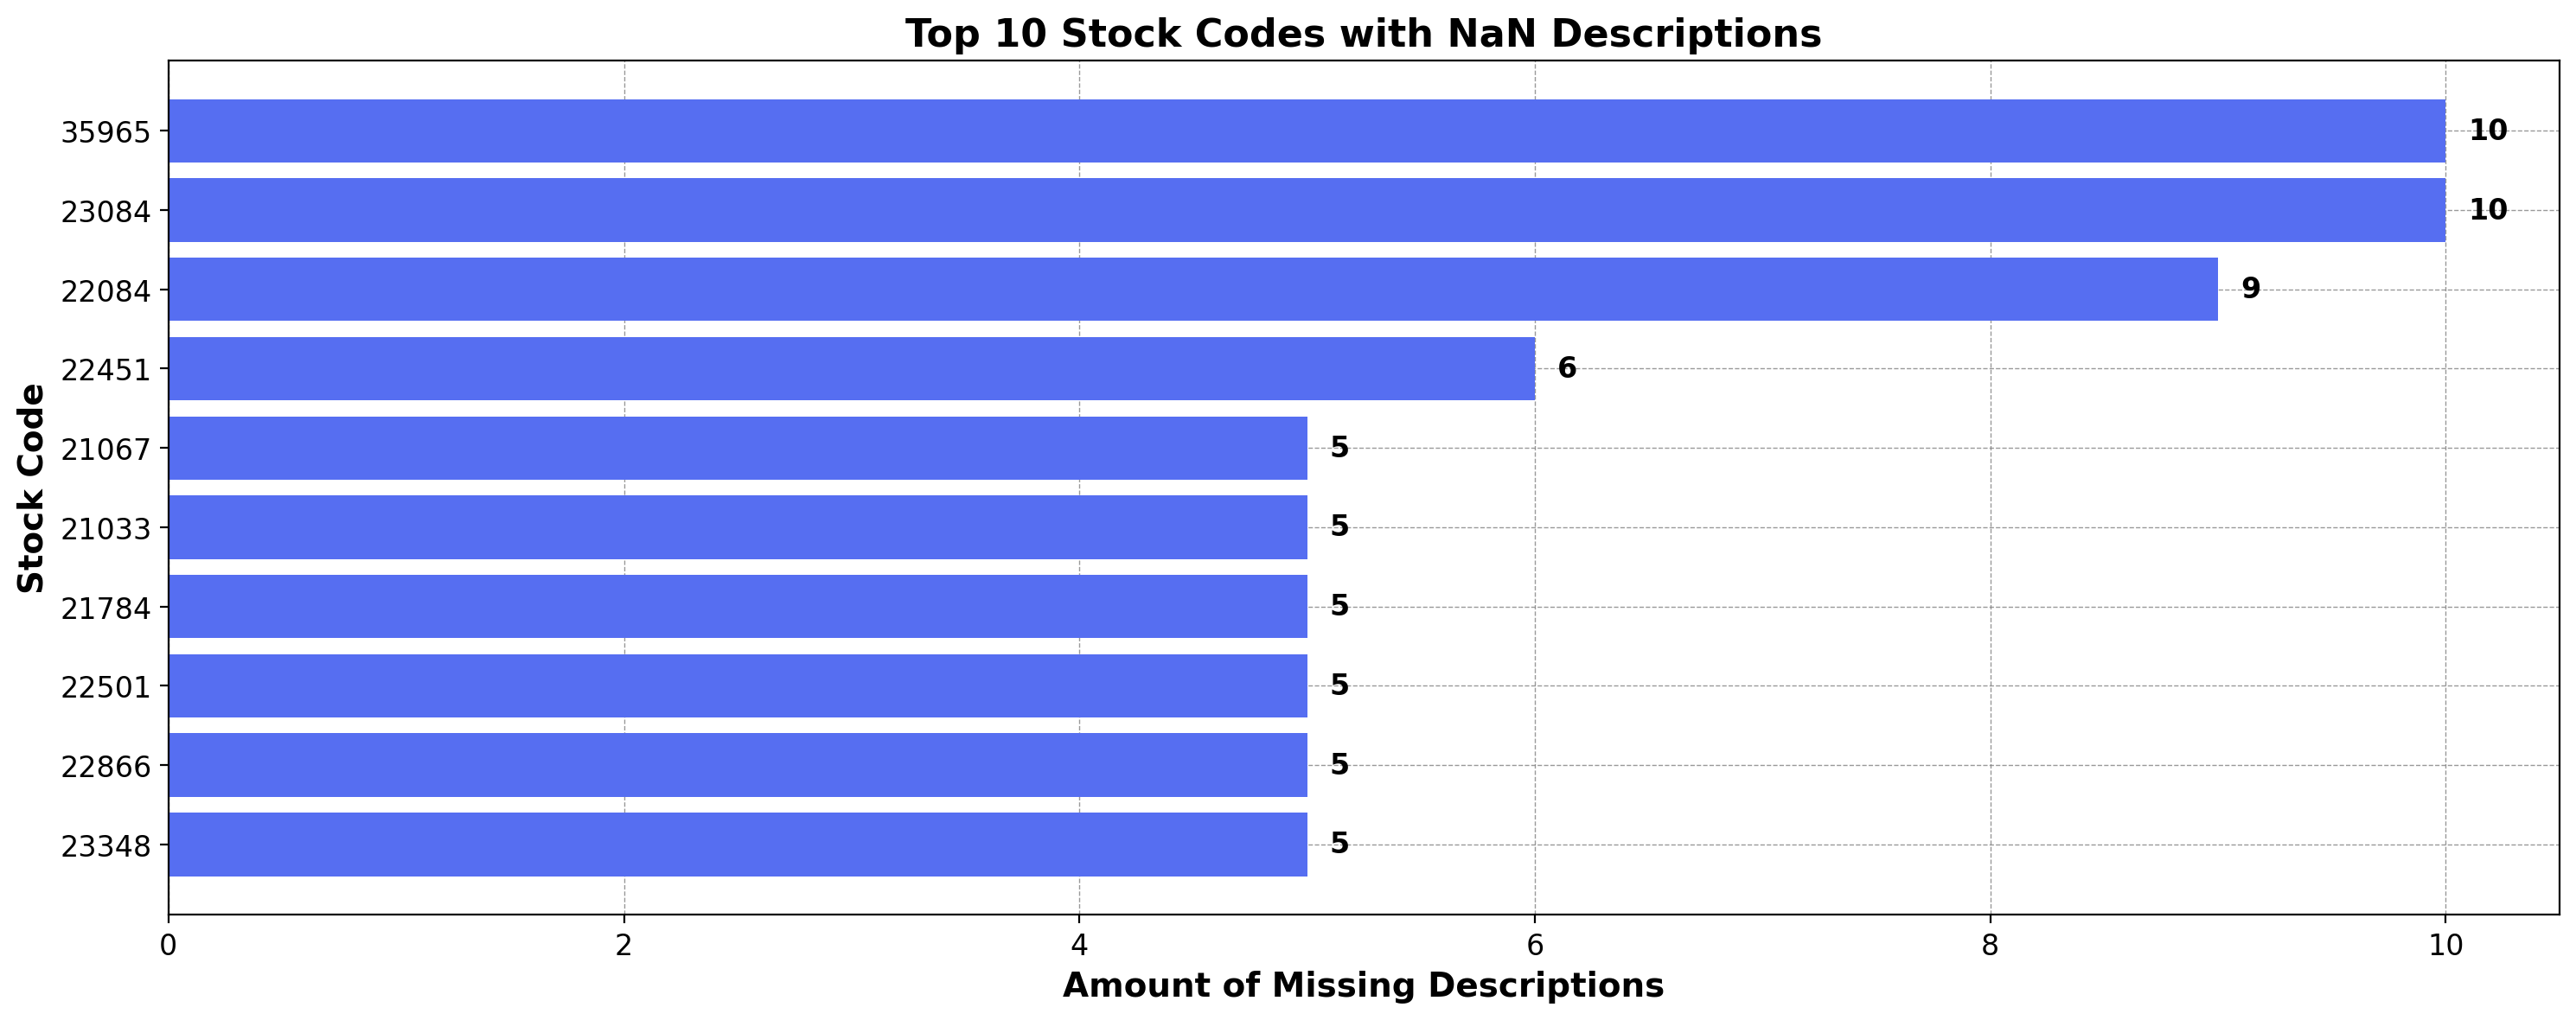

In [53]:
nan_descriptions = df[df['description'].isna()]
top_10_nan_stocks = nan_descriptions['stock_code'].value_counts().head(10).reset_index()
top_10_nan_stocks = top_10_nan_stocks.sort_values('count', ascending=True)
top_10_nan_stocks

#================== plot build =======================
fig, ax = plt.subplots(figsize = (15, 6), dpi = 100)
bars = ax.barh(top_10_nan_stocks['stock_code'], top_10_nan_stocks['count'], color = "#566ef1")

for bar in bars:
    width = bar.get_width()
    ax.text(width + (top_10_nan_stocks['count'].max() * 0.01),
            bar.get_y() + bar.get_height()/2, 
            f'{int(width)}', 
            va='center', ha='left', fontweight = 'bold', fontsize = 12)

#================== plot parameters ==================
#ax.set_xlim([0, top_10_nan_stocks['count'].max() * 1.15])
ax.set_title('Top 10 Stock Codes with NaN Descriptions', fontweight = 'bold', fontsize = 16)
ax.set_xlabel('Amount of Missing Descriptions', fontweight = 'bold', fontsize = 14)
ax.set_ylabel('Stock Code', fontweight = 'bold', fontsize = 14)

ax.set_axisbelow(True)
ax.grid(alpha = 0.8, color = 'gray', linestyle = '--', linewidth = 0.5)
ax.tick_params(axis = 'both', labelsize = 12)
plt.tight_layout()
plt.show()


The graph shows that most stock codes have fewer than $10$ records with missing descriptions. This is not a significant amount, and these records could be removed, as they represent only $0.24\%$ of the total dataset. However, one can try to benefit from these records by performing imputation of missing values. But first, for this data set, should check how many rows contain `NaN` in **both** the `customer_id` and `description` columns of this dataset. Since removing `NaN` of the `customer_id` (which will definitely be performed) may lead to removing most of `NaN` of the `description` records if they match. This would make the imputation procedure pointless.

In [54]:
both_nan_mask = df['customer_id'].isna() & df['description'].isna()
both_nan_count = both_nan_mask.sum()
print(f"Number of rows with NaN in both 'customer_id' and 'description' columns: {both_nan_count}")

Number of rows with NaN in both 'customer_id' and 'description' columns: 1454


Now that it is clear that all $1454$ records containing `NaN` in the `description` column match the records in the `customer_id` column and will therefore be deleted. Therefore, the imputation procedure is unnecessary.

The procedure for removing `NaN` values can now be performed.

In [55]:
missing_data_final = df.isnull().any(axis=1).sum()
missing_data_percentage_final = (missing_data_final / df.shape[0]) * 100
df = df.dropna()
print(f"\nHas been removed {missing_data_final} ({missing_data_percentage_final:.2f}%) records")
print("\nVerifying the removal of missing values -", df.isnull().sum().sum())


Has been removed 135080 (24.93%) records

Verifying the removal of missing values - 0


In [56]:
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   invoice_number    406829 non-null  str           
 1   stock_code        406829 non-null  str           
 2   description       406829 non-null  str           
 3   quantity          406829 non-null  int64         
 4   invoice_datetime  406829 non-null  datetime64[us]
 5   invoice_date      406829 non-null  object        
 6   invoice_time      406829 non-null  object        
 7   unit_price        406829 non-null  float64       
 8   customer_id       406829 non-null  object        
 9   country           406829 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(4)
memory usage: 54.1+ MB


### 2.4.4. Removing duplicate:

Before removing duplicate records, the first step is to visualise the proportion of missing values in relation to the total number of records.

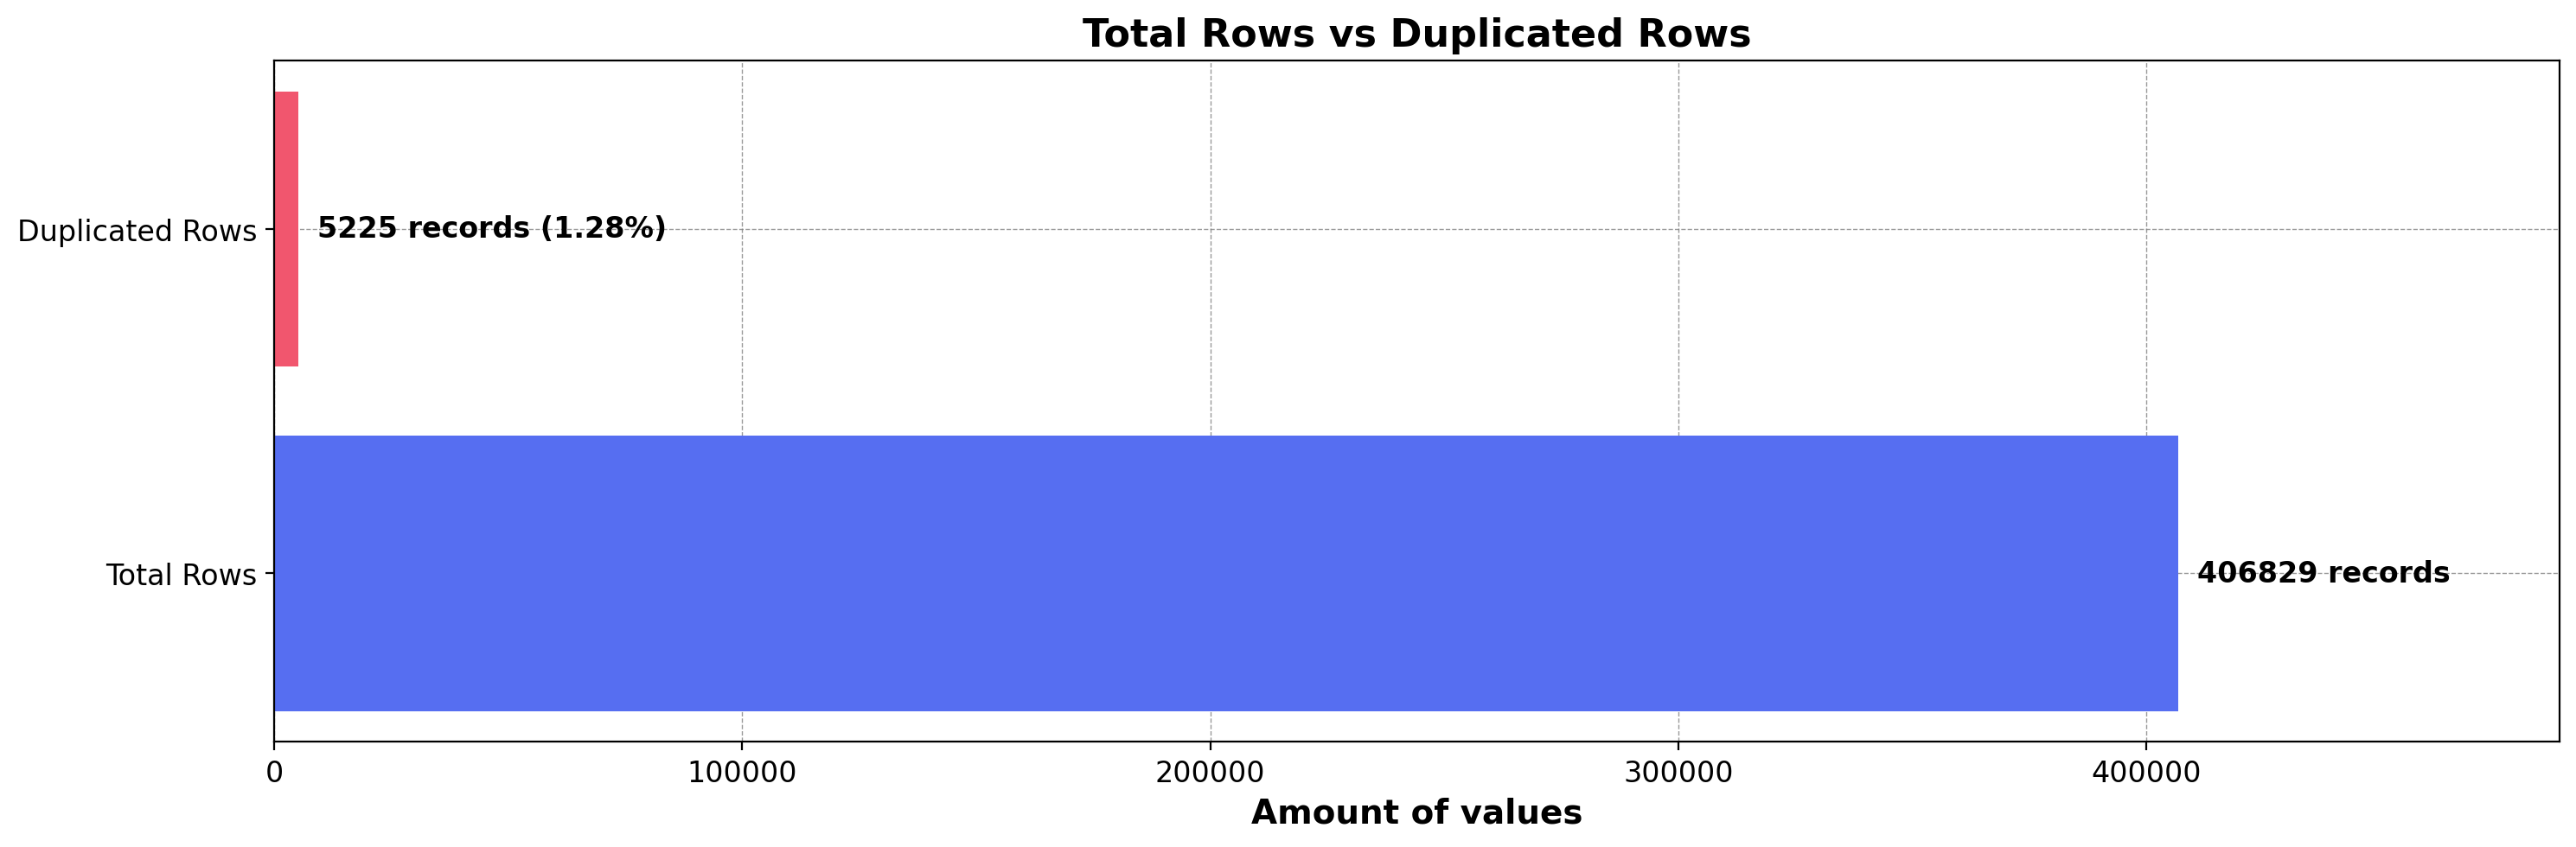

In [57]:
duplicated_data = df.duplicated().sum()
dublicated_data_percentage = float((duplicated_data / df.shape[0]) * 100)
total_rows = df.shape[0]

data_labels = ['Total Rows', 'Duplicated Rows']
data_values = [total_rows, duplicated_data]
colors = ['#566ef1', '#f1566e']

#================== plot build =======================
fig, ax = plt.subplots(figsize = (15, 5), dpi = 100)
bars = ax.barh(data_labels, data_values, color = colors)

for i, bar in enumerate(bars):
    value = bar.get_width()
    if i == 0:
        label = f'{value} records'
    else:
        label = f'{value} records ({dublicated_data_percentage:.2f}%)'
    ax.text(value + 4000, i, label, va = 'center', ha = 'left', fontweight = 'bold', fontsize = 12)

#================== plot parameters ==================
ax.set_xlim(0, total_rows * 1.2)
ax.set_title('Total Rows vs Duplicated Rows', fontweight = 'bold', fontsize = 16)
plt.xlabel('Amount of values', fontweight = 'bold', fontsize = 14)

ax.set_axisbelow(True)
ax.grid(alpha = 0.8, color = 'gray', linestyle = '--', linewidth = 0.5)
ax.tick_params(axis = 'both', labelsize = 12)
plt.tight_layout()
plt.show()

As illustrated in the graph, the number of duplicated records is $5225$, representing $1.28\%$ of the total. Before removing duplicates, should also examine these records in more detail to understand the nature of this error in the data.

In [58]:
duplicate_rows = df[df.duplicated(keep = False)]
duplicate_rows = duplicate_rows.sort_values(by = ['invoice_number', 'stock_code'])
duplicate_rows.head(15)

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,2010-12-01,11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,2010-12-01,11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,2010-12-01,11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,2010-12-01,11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2010-12-01,11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2010-12-01,11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2010-12-01,11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2010-12-01,11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,2010-12-01,11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,2010-12-01,11:49:00,1.65,17920.0,United Kingdom


As the results show, each record is processed at least twice (and sometimes more). Examining the transaction times reveals that they coincide to the second. Based on this information, it can be assumed that these are data entry errors rather than duplicate transactions. Therefore, these records should be deleted, as they introduce inaccuracy and distort further analysis.

In [59]:
print(f"Will be romved - {df.duplicated().sum()} ({dublicated_data_percentage:.2f}%) duplicated records.")
df = df.drop_duplicates()

print("\nVerifying the removal of duplicated records -", df.duplicated().sum())

Will be romved - 5225 (1.28%) duplicated records.

Verifying the removal of duplicated records - 0


In [60]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   invoice_number    401604 non-null  str           
 1   stock_code        401604 non-null  str           
 2   description       401604 non-null  str           
 3   quantity          401604 non-null  int64         
 4   invoice_datetime  401604 non-null  datetime64[us]
 5   invoice_date      401604 non-null  object        
 6   invoice_time      401604 non-null  object        
 7   unit_price        401604 non-null  float64       
 8   customer_id       401604 non-null  object        
 9   country           401604 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(4)
memory usage: 53.4+ MB


After basic cleaning and formatting of the data, it is necessary to save the intermediate dataset to record the result.

In [61]:
df.to_csv(processed_data_directory_path / "e-commerce-data-missing-duplicates-cleaned.csv", index = False, encoding = "ISO-8859-1")

### 2.4.5. Detecting and removing canceled orders
Check the data for canceled orders to withdraw from the dataset. Based on the previous analysis, which assumed that a negative quantity could indicate a goods return, let's examine these records in more detail.

In [62]:
df[df['quantity'] < 0].head(10)

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,2010-12-01,09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,2010-12-01,09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,2010-12-01,10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,2010-12-01,10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,2010-12-01,10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,2010-12-01,10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,2010-12-01,10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,2010-12-01,10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,2010-12-01,10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,2010-12-01,12:38:00,4.25,17897.0,United Kingdom


After evaluating the results, it is clear that records with negative values in the `quantity` column contained the letter $C$ in the invoice number values in the `invoice_number` column. 

Based on this, canceled orders can be identified using this pattern. The first step is to save records of canceled orders in a separate dataset, which will then be used to clean up the main dataset. This dataset can also be studied in a separate analysis.

In [63]:
df_canceled = df[df['invoice_number'].str.contains(r'[C]', regex = True)]
df_canceled.info()
df_canceled.head(10)

<class 'pandas.DataFrame'>
Index: 8872 entries, 141 to 541717
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   invoice_number    8872 non-null   str           
 1   stock_code        8872 non-null   str           
 2   description       8872 non-null   str           
 3   quantity          8872 non-null   int64         
 4   invoice_datetime  8872 non-null   datetime64[us]
 5   invoice_date      8872 non-null   object        
 6   invoice_time      8872 non-null   object        
 7   unit_price        8872 non-null   float64       
 8   customer_id       8872 non-null   object        
 9   country           8872 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(4)
memory usage: 1.2+ MB


,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,2010-12-01,09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,2010-12-01,09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,2010-12-01,10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,2010-12-01,10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,2010-12-01,10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,2010-12-01,10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,2010-12-01,10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,2010-12-01,10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,2010-12-01,10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,2010-12-01,12:38:00,4.25,17897.0,United Kingdom


Save the canceled orders in separate datraset.

In [64]:
df_canceled.to_csv(processed_data_directory_path / "e-commerce-data-canceled.csv", index = False, encoding = "ISO-8859-1")

Once the dataset for cancelled orders has been created, the proportion of cancelled orders in relation to all records is estimated prior to deleting this data.

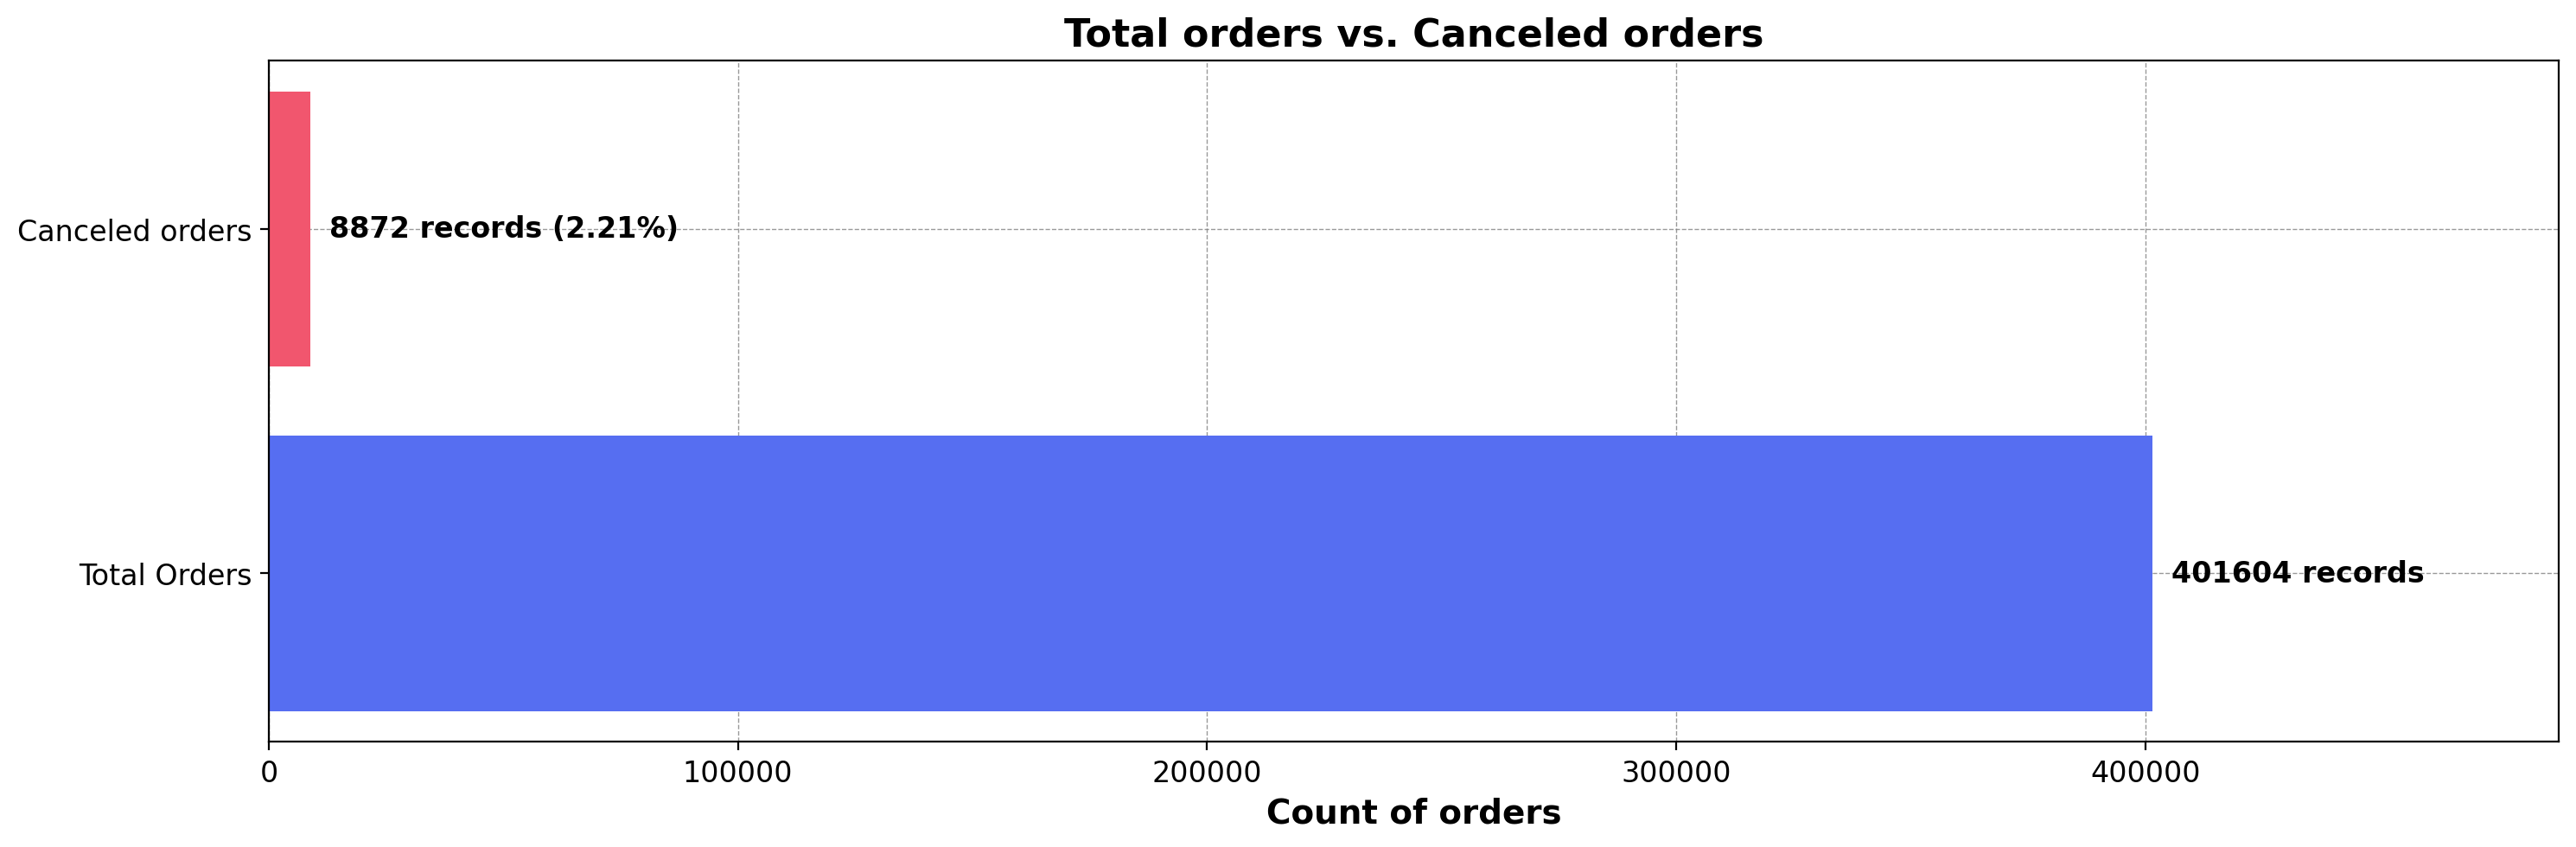

In [65]:
total_orders = df.shape[0]
tota_canceled_orders = df_canceled.shape[0]
percentage_canceled_orders = float((tota_canceled_orders / total_orders) * 100)

data_labels = ['Total Orders', 'Canceled orders']
data_values = [total_orders, tota_canceled_orders]
colors = ['#566ef1', '#f1566e']

#================== plot build =======================
fig, ax = plt.subplots(figsize = (15, 5), dpi = 100)
bars = ax.barh(data_labels, data_values, color = colors)

for i, bar in enumerate(bars):
    value = bar.get_width()
    if i == 0:
        label = f'{value} records'
    else:
        label = f'{value} records ({percentage_canceled_orders:.2f}%)'
    ax.text(value + 4000, i, label, va = 'center', ha = 'left', fontweight = 'bold', fontsize = 12)

ax.set_xlim(0, total_rows * 1.2)
ax.set_title('Total orders vs. Canceled orders', fontweight = 'bold', fontsize = 16)
plt.xlabel('Count of orders', fontweight = 'bold', fontsize = 14)

#================== plot parameters ==================
ax.set_axisbelow(True)
ax.grid(alpha = 0.8, color = 'gray', linestyle = '--', linewidth = 0.5)
ax.tick_params(axis = 'both', labelsize = 12)
plt.tight_layout()
plt.show()

As illustrated in the graph, the number of order transactions is $8872$, representing $2.21\%$ of the total orders.

Next, remove the canceled orders from the dataset

In [66]:
df = df[~df['invoice_number'].isin(df_canceled['invoice_number'])]
df.info()

print(f"\nHas been removed {tota_canceled_orders} ({percentage_canceled_orders:.2f}%) records")

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   invoice_number    392732 non-null  str           
 1   stock_code        392732 non-null  str           
 2   description       392732 non-null  str           
 3   quantity          392732 non-null  int64         
 4   invoice_datetime  392732 non-null  datetime64[us]
 5   invoice_date      392732 non-null  object        
 6   invoice_time      392732 non-null  object        
 7   unit_price        392732 non-null  float64       
 8   customer_id       392732 non-null  object        
 9   country           392732 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(4)
memory usage: 52.2+ MB

Has been removed 8872 (2.21%) records


### 2.4.6. Detecting Irrelevant Stock Codes

When identifying canceled orders, it was discovered that some Stock Codes contain all letters in addition to numbers. Therefore, it's important to identify and study which Stock Code variants contain such combinations. To do this, we first determine all the unique combinations of stock codes. The search will be performed among these.

In [67]:
unique_stock_codes = df['stock_code'].nunique()

print(f"Number of unique stock code - {unique_stock_codes}")

Number of unique stock code - 3665


The next step is to check the percentage of irrelevant stock codes among all the unique ones. From the previous steps, it was clear that the pattern for most stock codes is the presence of at least five consecutive numeric values. Based on the information provided, we will proceed to identify any irrelevant values.

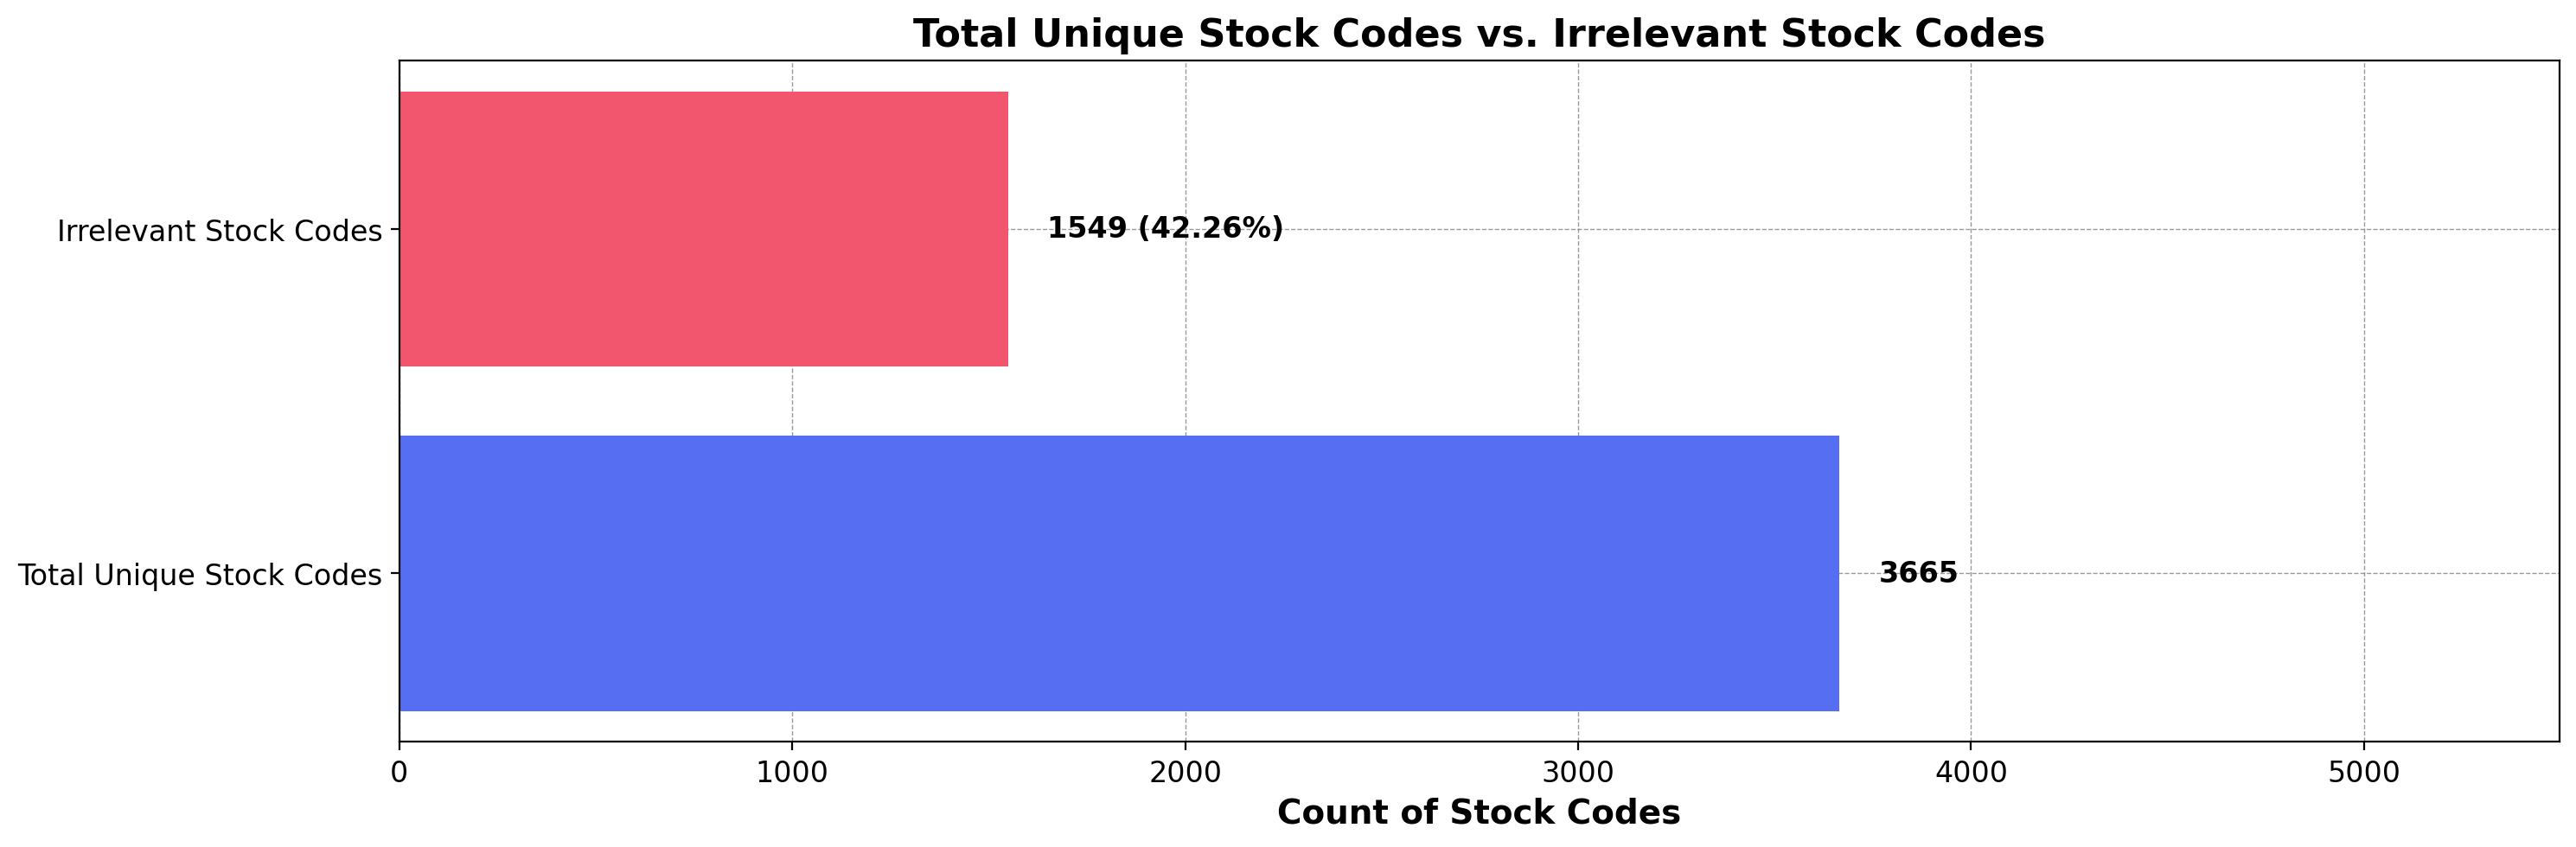

In [68]:
no_numeric_stock_codes = df[~df['stock_code'].astype(str).str.contains('^[0-9]{5}', regex = True)]

total_unique_stock_codes = unique_stock_codes
total_no_numeric_stock_codes = no_numeric_stock_codes.shape[0]
percentage_no_numeric_stock_codes = float((total_no_numeric_stock_codes / total_unique_stock_codes) * 100)

data_labels = ['Total Unique Stock Codes', 'Irrelevant Stock Codes']
data_values = [total_unique_stock_codes, total_no_numeric_stock_codes]
colors = ['#566ef1', '#f1566e']

#================== plot build =======================
fig, ax = plt.subplots(figsize = (15, 5), dpi = 100)
bars = ax.barh(data_labels, data_values, color = colors)

for i, bar in enumerate(bars):
    value = bar.get_width()
    if i == 0:
        label = f'{value}'
    else:
        label = f'{value} ({percentage_no_numeric_stock_codes:.2f}%)'
    ax.text(value + 100, i, label, va = 'center', ha = 'left', fontweight = 'bold', fontsize = 12)

ax.set_xlim(0, total_unique_stock_codes * 1.5)
ax.set_title('Total Unique Stock Codes vs. Irrelevant Stock Codes', fontweight = 'bold', fontsize = 16)
plt.xlabel('Count of Stock Codes', fontweight = 'bold', fontsize = 14)

#================== plot parameters ==================
ax.set_axisbelow(True)
ax.grid(alpha = 0.8, color = 'gray', linestyle = '--', linewidth = 0.5)
ax.tick_params(axis = 'both', labelsize = 12)
plt.tight_layout()
plt.show()

It is clear that irrelevant stock codes account for approximately $42\%$ of all unique values. The next step in the process is to ascertain the precise values of irrelevant stock codes and the transaction descriptions they contain. 

In [69]:
no_numeric_stock_codes_summary = no_numeric_stock_codes.groupby('stock_code')['description'].unique().reset_index()

print("--- Potential Non-Product Codes Found ---\n")
print(no_numeric_stock_codes_summary)

--- Potential Non-Product Codes Found ---

     stock_code                   description
0  BANK CHARGES                [Bank Charges]
1            C2                    [CARRIAGE]
2           DOT              [DOTCOM POSTAGE]
3             M                      [Manual]
4          PADS  [PADS TO MATCH ALL CUSHIONS]
5          POST                     [POSTAGE]


Expl

In [70]:
df[df['stock_code']=='PADS']

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-04-15 09:27:00,2011-04-15,09:27:00,0.001,13952.0,United Kingdom
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-07-26 10:13:00,2011-07-26,10:13:00,0.001,15618.0,United Kingdom
358655,568158,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 12:22:00,2011-09-25,12:22:00,0.000,16133.0,United Kingdom
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 14:58:00,2011-09-25,14:58:00,0.001,16198.0,United Kingdom


The obtained results indicate that irrelevant stock codes can be classified as "non-product transactions." To ensure that further analysis is as representative as possible, irrelevant stock codes should be excluded.

In [71]:
df = df[~df['stock_code'].isin(no_numeric_stock_codes['stock_code'])]
df.info()

total_percentage_no_numeric_stock_codes = float((total_no_numeric_stock_codes / df.shape[0]) * 100)
print(f"\nHas been removed {total_no_numeric_stock_codes} ({total_percentage_no_numeric_stock_codes:.2f}%) records")

<class 'pandas.DataFrame'>
Index: 391183 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   invoice_number    391183 non-null  str           
 1   stock_code        391183 non-null  str           
 2   description       391183 non-null  str           
 3   quantity          391183 non-null  int64         
 4   invoice_datetime  391183 non-null  datetime64[us]
 5   invoice_date      391183 non-null  object        
 6   invoice_time      391183 non-null  object        
 7   unit_price        391183 non-null  float64       
 8   customer_id       391183 non-null  object        
 9   country           391183 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(4)
memory usage: 52.1+ MB

Has been removed 1549 (0.40%) records


### 2.4.7. Normalizing Description Column

During the process of removing duplicates and missing values, it was discovered that the majority of the records contain product descriptions in the `description` column, written in uppercase. However, it was also noted that some of the records that were to be deleted were written in lowercase. Therefore, it is worth taking a closer look at the `description` column to check for entries written in lowercase that should be changed to uppercase or deleted altogether. Additionally, evaluate the information in this column in more detail during the process. It may contain irrelevant uppercase records that could be mistakenly included in the working dataset for further analysis.

First, let's display the values that are in the `description` column and are written in and/or contain lowercase letters.

In [72]:
preview_lower_case_description = df[df['description'].str.isupper() == False]
preview_lower_case_description_list = preview_lower_case_description['description'].unique()
for desc in preview_lower_case_description_list:
    print(desc)

BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
3 TRADITIONAl BISCUIT CUTTERS  SET
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
NUMBER TILE COTTAGE GARDEN No
POLYESTER FILLER PAD 30CMx30CM
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


From the list of values obtained `description`, "Next Day Carriage" and "High Resolution Image" can be considered irrelevant entries. However, they should first be examined in more detail.

In [73]:
df[(df['description'] == 'Next Day Carriage')]

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
205748,554835,23444,Next Day Carriage,1,2011-05-26 16:11:00,2011-05-26,16:11:00,15.0,15241.0,United Kingdom
209588,555251,23444,Next Day Carriage,1,2011-06-01 15:12:00,2011-06-01,15:12:00,15.0,13062.0,United Kingdom
210691,555312,23444,Next Day Carriage,1,2011-06-02 10:39:00,2011-06-02,10:39:00,15.0,16484.0,United Kingdom
211341,555367,23444,Next Day Carriage,1,2011-06-02 14:28:00,2011-06-02,14:28:00,15.0,17900.0,United Kingdom
218011,555948,23444,Next Day Carriage,1,2011-06-08 10:49:00,2011-06-08,10:49:00,30.0,13752.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
525425,580622,23444,Next Day Carriage,1,2011-12-05 12:09:00,2011-12-05,12:09:00,15.0,17006.0,United Kingdom
525438,580630,23444,Next Day Carriage,1,2011-12-05 12:11:00,2011-12-05,12:11:00,15.0,12913.0,United Kingdom
534091,581132,23444,Next Day Carriage,1,2011-12-07 12:55:00,2011-12-07,12:55:00,15.0,17590.0,United Kingdom
536863,581221,23444,Next Day Carriage,1,2011-12-08 09:40:00,2011-12-08,09:40:00,15.0,17856.0,United Kingdom


In [74]:
df[(df['description'] == 'High Resolution Image')]

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
406162,571739,23702,High Resolution Image,1,2011-10-19 10:33:00,2011-10-19,10:33:00,3.0,12500.0,Germany
460380,575910,23702,High Resolution Image,2,2011-11-11 16:05:00,2011-11-11,16:05:00,1.5,14836.0,United Kingdom
471983,576659,23702,High Resolution Image,1,2011-11-16 11:09:00,2011-11-16,11:09:00,21.0,15373.0,United Kingdom


After evaluating these transactions in more detail, it was concluded that they could be excluded from the data set, as they appear to be administrative records that are not required for further analysis.

In [75]:
irrelavant_description = df[(df['description'] == 'Next Day Carriage') | (df['description'] == 'High Resolution Image')]
number_irrelavant_description = irrelavant_description.shape[0]
percentage_irrelavant_description = float((number_irrelavant_description / df.shape[0]) * 100)
df = df[~df['description'].isin(irrelavant_description['description'])]
df.info()

print(f"\nHas been removed {number_irrelavant_description} ({percentage_irrelavant_description:.2f}%) records")


<class 'pandas.DataFrame'>
Index: 391101 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   invoice_number    391101 non-null  str           
 1   stock_code        391101 non-null  str           
 2   description       391101 non-null  str           
 3   quantity          391101 non-null  int64         
 4   invoice_datetime  391101 non-null  datetime64[us]
 5   invoice_date      391101 non-null  object        
 6   invoice_time      391101 non-null  object        
 7   unit_price        391101 non-null  float64       
 8   customer_id       391101 non-null  object        
 9   country           391101 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(4)
memory usage: 52.0+ MB

Has been removed 82 (0.02%) records


### 2.4.8. Removing zero price records

At this stage, in order to ensure the commercial reliability of the data, it was decided to check the `unit_price` column for zero values.

In [76]:
zero_price_transaction = df[(df['unit_price'] == 0)]
zero_price_transaction.describe()

,quantity,invoice_datetime,unit_price
count,33.000000,33,33.0
mean,420.515152,2011-07-09 21:24:10.909091,0.0
min,1.000000,2010-12-05 14:02:00,0.0
25%,2.000000,2011-03-30 12:45:00,0.0
50%,11.000000,2011-08-26 14:19:00,0.0
75%,36.000000,2011-11-04 11:55:00,0.0
max,12540.000000,2011-11-25 15:57:00,0.0
std,2176.713608,NaN,0.0


In [77]:
zero_price_transaction

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,2010-12-05,14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,2010-12-16,14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,2010-12-21,13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,2011-01-06,16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,2011-01-06,16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,2011-01-13,15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,2011-02-10,13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,2011-03-23,10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,2011-03-30,12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,2011-04-04,14:42:00,0.0,14410.0,United Kingdom


Upon closer inspection, it can be seen that the dataset at this stage has $33$ transactions with a price value of $0$. Considering the significance of other parameters of these transactions, such as `stock_code`, `description`, `quantity`, and `customer_id`, we can conclude that these are not operational adjustments (inventory corrections, damaged goods write-offs, or manual entries). Therefore, in order not to distort the results of further analysis, these records should be deleted.

In [78]:
total_zero_price_transaction = zero_price_transaction.shape[0]
percentage_total_zero_price_transaction = float((total_zero_price_transaction / df.shape[0]) * 100)

df = df[df['unit_price'] > 0]
df.info()

print(f"\nHas been removed {total_zero_price_transaction} ({percentage_total_zero_price_transaction:.2f}%) records")

<class 'pandas.DataFrame'>
Index: 391068 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   invoice_number    391068 non-null  str           
 1   stock_code        391068 non-null  str           
 2   description       391068 non-null  str           
 3   quantity          391068 non-null  int64         
 4   invoice_datetime  391068 non-null  datetime64[us]
 5   invoice_date      391068 non-null  object        
 6   invoice_time      391068 non-null  object        
 7   unit_price        391068 non-null  float64       
 8   customer_id       391068 non-null  object        
 9   country           391068 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(4)
memory usage: 52.0+ MB

Has been removed 33 (0.01%) records


Saving the cleaned data set.

In [79]:
df.to_csv(processed_data_directory_path / "e-commerce-data-cleaned.csv", index = False, encoding = "ISO-8859-1")

## 2.5. Results of Data Cleaning
During this section, the size of the dataset changed as follows

|**Step**|**Amount of Records**|**Deleted Records**|**Deleted Percentage**|
|:-------|:-------------------:|:-----------------:|:--------------------:|
|2.4.3. Detect and fix/drop `NAN` values        |$541909$|$135080$  |$24.93\%$  |
|2.4.4. Removing dublicate                      |$406829$|$5225$    |$1.28\%$   |
|2.4.5. Detecting and removing canceled orders  |$401604$|$8872$    |$2.21\%$   |
|2.4.6. Detecting Irrelevant stock codes        |$392732$|$1549$    |$0.40\%$   |
|2.4.7. Normalizing Description Column          |$391183$|$82$      |$0.02\%$   |
|2.4.8. Removing zero price records             |$391101$|$33$      |$0.01\%$   |

**Amount of rows in cleaned dataset** - $391068$